# Fashion-MNIST Image Classification with Deep Learning
**Module:** WMG9B7-15 – Artificial Intelligence & Deep Learning  
**Author:** Takuya Otsuki

---

## README

**How to run:** Open this notebook in Azure ML Studio (Python 3.10 – AzureML, Standard T4) and select **Run All**. No local files are required — the dataset is downloaded automatically.

**Project summary:** This notebook trains a Convolutional Neural Network (CNN) on the Fashion-MNIST dataset to classify clothing items into 10 categories. An MLP baseline is included for comparison.

**Project structure:**
1. Environment Setup — install dependencies and configure device
2. Dataset Loading & Preprocessing — download Fashion-MNIST via torchvision, apply transforms
3. Exploratory Data Analysis — sample images and class distribution
4. Model Architectures — MLP baseline (4a) and CNN (4b)
5. Training — train both models with the same settings for fair comparison
6. Evaluation — accuracy comparison, confusion matrix, classification report
7. Results Visualisation — training curves and sample predictions

**Dataset:** Fashion-MNIST (Zalando Research) — fetched via `torchvision.datasets` (MIT Licence).  
**Dataset citation:** Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms*. arXiv:1708.07747.

**Runtime note:** Training runs for 10 epochs and completes within 15 minutes on Azure ML Standard T4.

---
## 1. Environment Setup
Install and import all required libraries.

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --quiet
!pip install matplotlib seaborn scikit-learn numpy --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

---
## 2. Dataset Loading & Preprocessing
Download Fashion-MNIST programmatically via torchvision. No local files are used.

The following transforms are applied:
- **ToTensor()** — converts PIL image (H×W, uint8) to a float tensor (1×28×28) scaled to [0, 1]
- **Normalize((0.5,), (0.5,))** — rescales pixel values from [0, 1] to [−1, 1], centring the data around zero to stabilise training

In [3]:
DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

raw_train = datasets.FashionMNIST(root=DATA_DIR, train=True,  download=True, transform=transform)
raw_test  = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform)

train_loader = DataLoader(raw_train, batch_size=64, shuffle=True)
test_loader  = DataLoader(raw_test,  batch_size=64, shuffle=False)

print(f'Train samples : {len(raw_train)}')
print(f'Test  samples : {len(raw_test)}')

Train samples : 60000
Test  samples : 10000


---
## 3. Exploratory Data Analysis (EDA)
Understand the dataset: class distribution, sample images, and basic statistics.

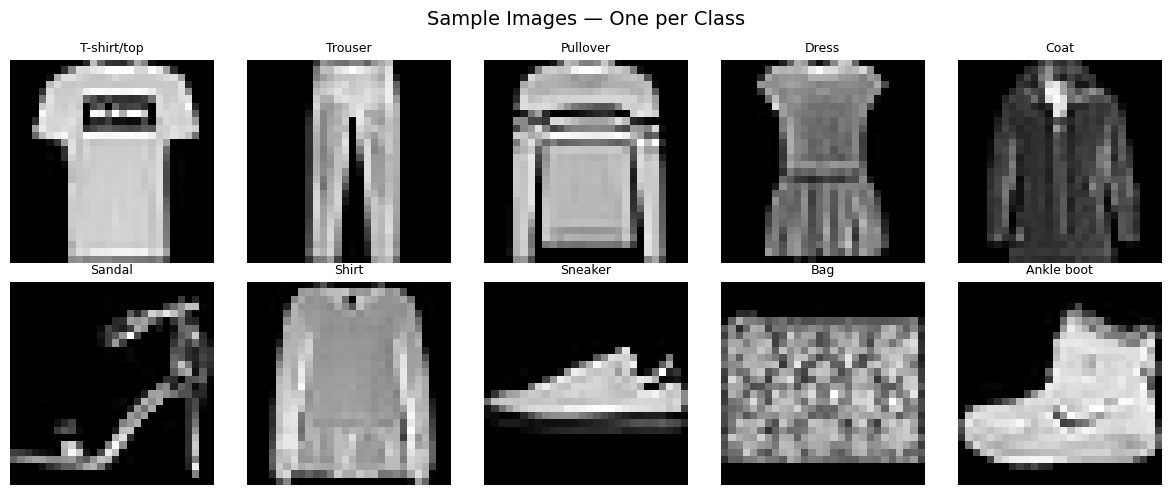

In [4]:
# Sample images per class (using raw pixel data before normalisation)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Images — One per Class', fontsize=14)

for i, ax in enumerate(axes.flat):
    # Find first image of class i
    idx = (raw_train.targets == i).nonzero(as_tuple=True)[0][0].item()
    image = raw_train.data[idx].numpy()  # raw uint8 tensor → numpy
    ax.imshow(image, cmap='gray')
    ax.set_title(CLASS_NAMES[i], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

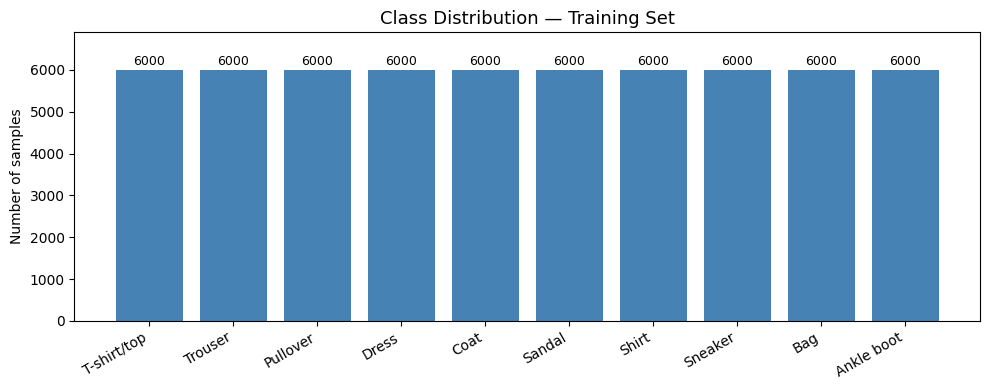

Classes are balanced
Min: 6000 samples | Max: 6000 samples


In [5]:
# Class distribution in training set
label_counts = [(raw_train.targets == i).sum().item() for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, label_counts, color='steelblue')
ax.set_title('Class Distribution — Training Set', fontsize=13)
ax.set_ylabel('Number of samples')
ax.set_ylim(0, max(label_counts) * 1.15)
plt.xticks(rotation=30, ha='right')

for bar, count in zip(bars, label_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Classes are {"balanced" if max(label_counts) - min(label_counts) < 500 else "imbalanced"}')
print(f'Min: {min(label_counts)} samples | Max: {max(label_counts)} samples')

---
## 4. Model Architectures
### 4a. Baseline — MLP (Multi-Layer Perceptron)
Flattens the 28×28 image into a 784-dimensional vector and uses fully connected layers. No spatial awareness.

In [16]:
# Define MLP baseline model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.model(x)

mlp = MLP().to(device)
print(mlp)

MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=10, bias=True)
  )
)


### 4b. Main Model — CNN (Convolutional Neural Network)
Uses convolutional layers to detect spatial features hierarchically. Designed to exploit the 2D structure of images.

In [17]:
# Define CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 32×28×28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 32×14×14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 64×14×14
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                            # 64×7×7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn = CNN().to(device)
print(cnn)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [18]:
# Print model summaries (MLP and CNN)
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'MLP parameters : {count_params(mlp):,}')
print(f'CNN parameters : {count_params(cnn):,}')

MLP parameters : 535,818
CNN parameters : 1,630,090


---
## 5. Training
Train both models separately using the same loss function, optimiser settings, and number of epochs for a fair comparison.

In [33]:
EPOCHS = 10
criterion = nn.CrossEntropyLoss()

def train_model(model, optimiser, num_epochs=EPOCHS):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimiser.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimiser.step()

            running_loss += loss.item() * images.size(0)
            correct += outputs.argmax(1).eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # --- Validation ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss    += criterion(outputs, labels).item() * images.size(0)
                val_correct += outputs.argmax(1).eq(labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch [{epoch+1:02d}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  '
              f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}')

    return history

In [34]:
print('Training MLP baseline...')
mlp_optimiser = optim.Adam(mlp.parameters(), lr=0.001)
mlp_history = train_model(mlp, mlp_optimiser)

Training MLP baseline...
Epoch [01/10] Train Loss: 0.3078  Train Acc: 0.8881  Val Loss: 0.3470  Val Acc: 0.8769
Epoch [02/10] Train Loss: 0.2978  Train Acc: 0.8912  Val Loss: 0.3373  Val Acc: 0.8785
Epoch [03/10] Train Loss: 0.2930  Train Acc: 0.8916  Val Loss: 0.3441  Val Acc: 0.8765
Epoch [04/10] Train Loss: 0.2862  Train Acc: 0.8941  Val Loss: 0.3312  Val Acc: 0.8829
Epoch [05/10] Train Loss: 0.2850  Train Acc: 0.8939  Val Loss: 0.3313  Val Acc: 0.8826
Epoch [06/10] Train Loss: 0.2761  Train Acc: 0.8976  Val Loss: 0.3305  Val Acc: 0.8848
Epoch [07/10] Train Loss: 0.2747  Train Acc: 0.8985  Val Loss: 0.3325  Val Acc: 0.8838
Epoch [08/10] Train Loss: 0.2714  Train Acc: 0.8985  Val Loss: 0.3313  Val Acc: 0.8869
Epoch [09/10] Train Loss: 0.2631  Train Acc: 0.9016  Val Loss: 0.3364  Val Acc: 0.8842
Epoch [10/10] Train Loss: 0.2615  Train Acc: 0.9022  Val Loss: 0.3292  Val Acc: 0.8846


In [35]:
print('Training CNN...')
cnn_optimiser = optim.Adam(cnn.parameters(), lr=0.001)
cnn_history = train_model(cnn, cnn_optimiser)

Training CNN...
Epoch [01/10] Train Loss: 0.0989  Train Acc: 0.9634  Val Loss: 0.2602  Val Acc: 0.9249
Epoch [02/10] Train Loss: 0.0903  Train Acc: 0.9661  Val Loss: 0.2689  Val Acc: 0.9228
Epoch [03/10] Train Loss: 0.0804  Train Acc: 0.9700  Val Loss: 0.2939  Val Acc: 0.9254
Epoch [04/10] Train Loss: 0.0741  Train Acc: 0.9719  Val Loss: 0.3030  Val Acc: 0.9260
Epoch [05/10] Train Loss: 0.0663  Train Acc: 0.9752  Val Loss: 0.3190  Val Acc: 0.9256
Epoch [06/10] Train Loss: 0.0638  Train Acc: 0.9764  Val Loss: 0.3343  Val Acc: 0.9258
Epoch [07/10] Train Loss: 0.0602  Train Acc: 0.9779  Val Loss: 0.3224  Val Acc: 0.9269
Epoch [08/10] Train Loss: 0.0540  Train Acc: 0.9801  Val Loss: 0.3396  Val Acc: 0.9239
Epoch [09/10] Train Loss: 0.0508  Train Acc: 0.9808  Val Loss: 0.3622  Val Acc: 0.9240
Epoch [10/10] Train Loss: 0.0496  Train Acc: 0.9817  Val Loss: 0.3761  Val Acc: 0.9244


---
## 6. Evaluation
Compare MLP and CNN on the test set using accuracy, confusion matrix, and per-class metrics.

In [36]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds = model(images).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    return torch.cat(all_preds), torch.cat(all_labels)

mlp_preds, true_labels = evaluate(mlp, test_loader)
cnn_preds, _           = evaluate(cnn, test_loader)

mlp_acc = (mlp_preds == true_labels).float().mean().item()
cnn_acc = (cnn_preds == true_labels).float().mean().item()

print(f'MLP Test Accuracy : {mlp_acc:.4f} ({mlp_acc*100:.2f}%)')
print(f'CNN Test Accuracy : {cnn_acc:.4f} ({cnn_acc*100:.2f}%)')
print(f'CNN improvement   : +{(cnn_acc - mlp_acc)*100:.2f}%')

MLP Test Accuracy : 0.8846 (88.46%)
CNN Test Accuracy : 0.9244 (92.44%)
CNN improvement   : +3.98%


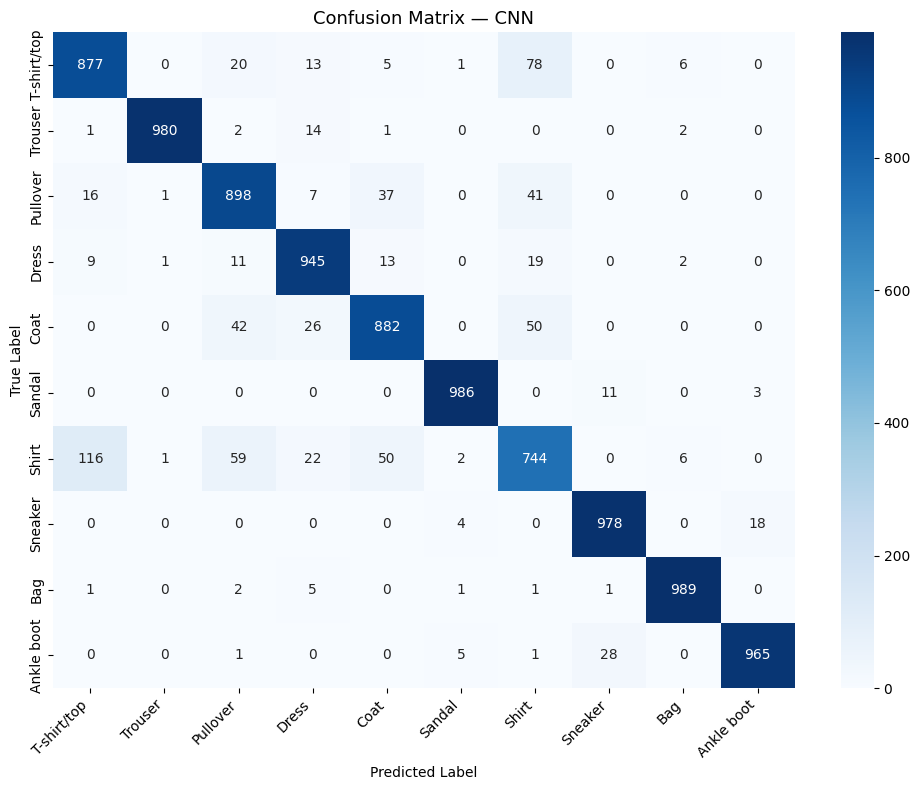


Classification Report — CNN
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.88      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.87      0.90      0.88      1000
       Dress       0.92      0.94      0.93      1000
        Coat       0.89      0.88      0.89      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.80      0.74      0.77      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.98      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [37]:
# Confusion matrix — CNN
cm = confusion_matrix(true_labels, cnn_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — CNN', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Per-class metrics — CNN
print('\nClassification Report — CNN')
print(classification_report(true_labels, cnn_preds, target_names=CLASS_NAMES))

---
## 7. Results Visualisation
Plot training curves for both models and visualise CNN predictions.

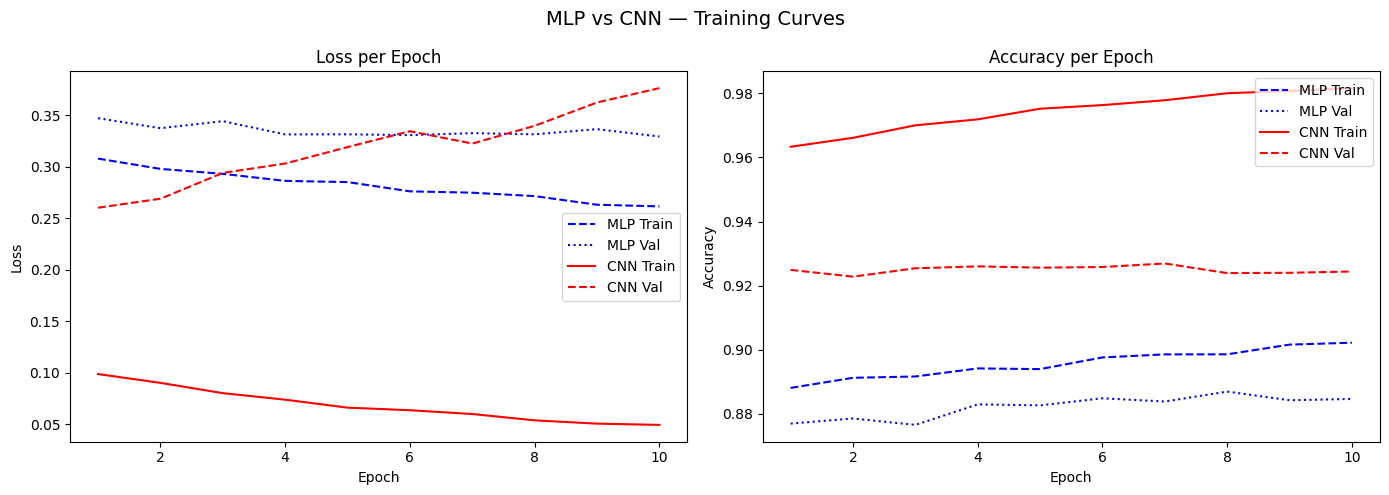

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, mlp_history['train_loss'], 'b--', label='MLP Train')
axes[0].plot(epochs_range, mlp_history['val_loss'],   'b:',  label='MLP Val')
axes[0].plot(epochs_range, cnn_history['train_loss'], 'r-',  label='CNN Train')
axes[0].plot(epochs_range, cnn_history['val_loss'],   'r--', label='CNN Val')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, mlp_history['train_acc'], 'b--', label='MLP Train')
axes[1].plot(epochs_range, mlp_history['val_acc'],   'b:',  label='MLP Val')
axes[1].plot(epochs_range, cnn_history['train_acc'], 'r-',  label='CNN Train')
axes[1].plot(epochs_range, cnn_history['val_acc'],   'r--', label='CNN Val')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('MLP vs CNN — Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

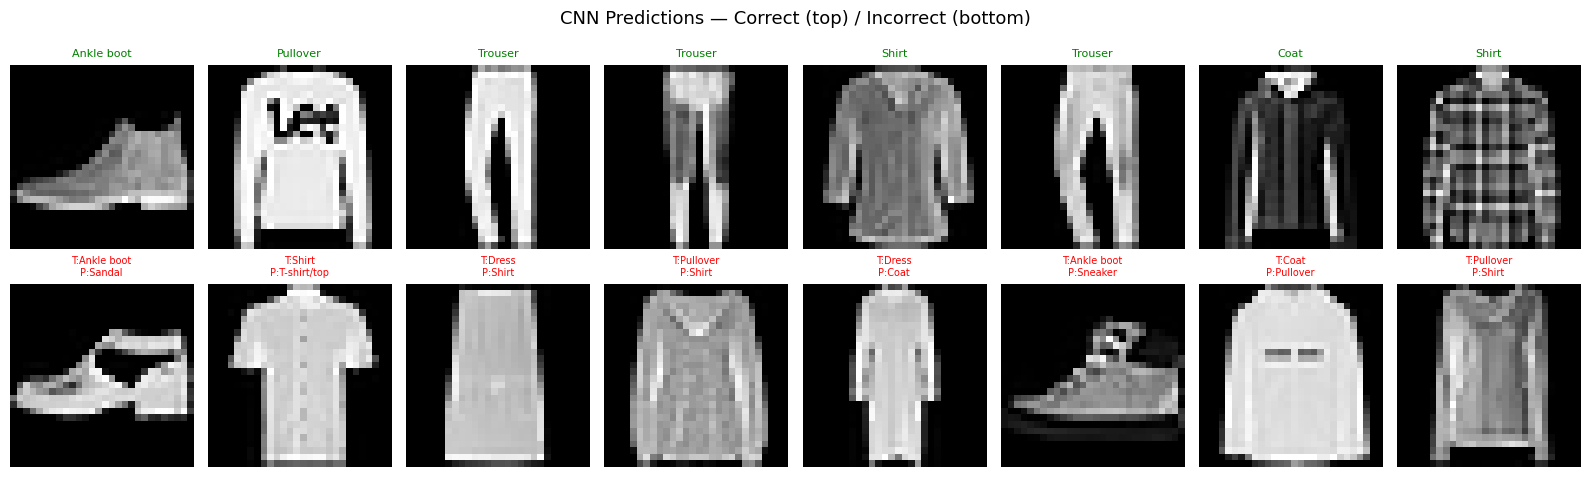

In [41]:
# Sample predictions — correct and incorrect
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('CNN Predictions — Correct (top) / Incorrect (bottom)', fontsize=13)

correct_shown, incorrect_shown = 0, 0

for image, true_label, pred_label in zip(raw_test.data, true_labels, cnn_preds):
    if correct_shown < 8 and true_label == pred_label:
        ax = axes[0][correct_shown]
        ax.imshow(image.numpy(), cmap='gray')
        ax.set_title(CLASS_NAMES[true_label], fontsize=8, color='green')
        ax.axis('off')
        correct_shown += 1

    elif incorrect_shown < 8 and true_label != pred_label:
        ax = axes[1][incorrect_shown]
        ax.imshow(image.numpy(), cmap='gray')
        ax.set_title(f'T:{CLASS_NAMES[true_label]}\nP:{CLASS_NAMES[pred_label]}',
                     fontsize=7, color='red')
        ax.axis('off')
        incorrect_shown += 1

    if correct_shown == 8 and incorrect_shown == 8:
        break

plt.tight_layout()
plt.show()